# Reinforcement Learning Laboratory
## Lab Assignment 3: GridWorld – Policy Evaluation and Value Iteration
- **Course Outcomes:** CO2 (Dynamic Programming & Policy Iteration), CO3 (Value Iteration & Bellman Optimality), CO4 (Policy Analysis & Path Planning)
- **Duration:** 3 Hours
- **Repository:** Amrita DRL Lab Series

---

### Objectives
1. Formulate a discrete **GridWorld Environment** as a formal Markov Decision Process $(\mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma)$.
2. Implement **Iterative Policy Evaluation** using the Bellman Expectation Equation to evaluate an arbitrary (uniform random) policy.
3. Implement **Value Iteration** using the Bellman Optimality Equation to derive the optimal state-value function $V^*(s)$ and extract the optimal deterministic policy $\pi^*(s)$.
4. Compare simulated trajectories generated by **Random Policy**, **Evaluated Suboptimal Policy**, and **Optimal Policy**.
5. Answer all analytical and theoretical questions in depth.

## Task 1: Formulating the GridWorld Environment

We define a standard $4 \times 4$ GridWorld environment with coordinates $(r, c) \in \{0,1,2,3\}^2$:
- **States (16 States):** $S_0, S_1, \dots, S_{15}$ where state $s = 4r + c$.
  - Start State: $S_0 = (0,0)$ (Top-Left)
  - Goal State (Terminal): $S_{15} = (3,3)$ (Bottom-Right, Reward $R = +10$)
  - Pitfall / Danger State: $S_5 = (1,1)$ (Reward $R = -5$)
  - Wall / Obstacle: $S_6 = (1,2)$ (Inaccessible cell / bounce back)
- **Actions:** 4 cardinal movements $\mathcal{A} = \{\text{Up} (0), \text{Right} (1), \text{Down} (2), \text{Left} (3)\}$.
- **Transition Dynamics:** Deterministic grid transitions with boundary walls.
- **Reward Function:** Step penalty $R = -1$ for regular transitions, $R = +10$ on entering the Goal state, $R = -5$ on entering the Danger cell.
- **Discount Factor:** $\gamma = 0.90$.

| RL Component | Formulation & Description |
| :--- | :--- |
| **States ($\mathcal{S}$)** | 16 discrete states $S_0$ through $S_{15}$ representing 2D grid coordinates $(r, c)$ on a $4 \times 4$ grid. |
| **Actions ($\mathcal{A}$)** | 4 discrete actions: $\mathcal{A} = \{\text{Up (0), Right (1), Down (2), Left (3)}\}$. Boundary collisions leave position unchanged. |
| **Reward Structure ($\mathcal{R}$)** | $R(s, a, s') = -1$ per step (encouraging shortest path), $R(s, a, S_{15}) = +10$ at Goal, $R(s, a, S_5) = -5$ at Danger pitfall. |
| **Terminal State(s)** | $S_{15} = (3, 3)$ (Goal state where simulation terminates and $V(S_{15}) = 0$). |
| **Goal of the Agent** | Find an optimal policy $\pi^*(s)$ that maximizes expected cumulative discounted return $G_t = \sum_{k=0}^\infty \gamma^k R_{t+k+1}$. |

In [1]:
# Complete GridWorld MDP Implementation in Python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class GridWorldMDP:
    """4x4 GridWorld MDP with Obstacles, Danger Zones, and Goal"""
    def __init__(self, rows=4, cols=4, gamma=0.9):
        self.rows = rows
        self.cols = cols
        self.gamma = gamma
        self.n_states = rows * cols
        
        # Define Special States
        self.start_state = 0   # (0, 0)
        self.goal_state = 15   # (3, 3) - Terminal (+10)
        self.danger_state = 5  # (1, 1) - Penalty (-5)
        self.obstacle_state = 6 # (1, 2) - Impassable Wall
        self.terminal_states = {self.goal_state}
        
        # Actions: 0: Up, 1: Right, 2: Down, 3: Left
        self.actions = [0, 1, 2, 3]
        self.action_names = {0: "↑ Up", 1: "→ Right", 2: "↓ Down", 3: "← Left"}
        self.action_vectors = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
        
    def state_to_coord(self, s):
        return s // self.cols, s % self.cols

    def coord_to_state(self, r, c):
        return r * self.cols + c

    def get_transition_dynamics(self, s, a):
        """Return list of (prob, next_state, reward, is_terminal)"""
        if s in self.terminal_states:
            return [(1.0, s, 0.0, True)]
        
        r, c = self.state_to_coord(s)
        dr, dc = self.action_vectors[a]
        next_r, next_c = r + dr, c + dc
        
        # Check boundary collision
        if not (0 <= next_r < self.rows and 0 <= next_c < self.cols):
            next_r, next_c = r, c # Hit border wall, stay in place
            
        next_s = self.coord_to_state(next_r, next_c)
        
        # Check obstacle collision
        if next_s == self.obstacle_state:
            next_s = s # Hit obstacle, stay in place
            
        # Reward determination
        if next_s == self.goal_state:
            reward = 10.0
            is_term = True
        elif next_s == self.danger_state:
            reward = -5.0
            is_term = False
        else:
            reward = -1.0 # Step cost
            is_term = False
            
        return [(1.0, next_s, reward, is_term)]

grid = GridWorldMDP()
print("GridWorld MDP Environment successfully initialized!")
print(f"Total States: {grid.n_states} | Goal State: {grid.goal_state} | Danger State: {grid.danger_state} | Obstacle: {grid.obstacle_state}")

GridWorld MDP Environment successfully initialized!
Total States: 16 | Goal State: 15 | Danger State: 5 | Obstacle: 6


## Task 2: Policy Evaluation

**Policy Evaluation** computes the state-value function $V^\pi(s)$ for an arbitrary given policy $\pi(a|s)$ using the **Bellman Expectation Equation**:

$$V_{k+1}(s) = \sum_{a \in \mathcal{A}} \pi(a|s) \sum_{s', r} \mathcal{P}(s', r \mid s, a) \left[ r + \gamma V_k(s') \right]$$

We evaluate the **Equiprobable Uniform Random Policy** where $\pi(a|s) = 0.25$ for all actions $a \in \{0,1,2,3\}$.
We track the maximum value change $\Delta = \max_{s} |V_{k+1}(s) - V_k(s)|$ at each iteration until convergence with tolerance $\theta = 10^{-4}$.

In [2]:
# Task 2: Iterative Policy Evaluation
def policy_evaluation(env, policy, theta=1e-4):
    V = np.zeros(env.n_states)
    history = []
    iteration = 0
    
    while True:
        iteration += 1
        delta = 0.0
        V_new = np.zeros(env.n_states)
        
        for s in range(env.n_states):
            if s in env.terminal_states:
                V_new[s] = 0.0
                continue
            
            v_val = 0.0
            for a in env.actions:
                prob_a = policy[s, a]
                transitions = env.get_transition_dynamics(s, a)
                for prob_trans, next_s, r, is_term in transitions:
                    v_val += prob_a * prob_trans * (r + env.gamma * (0.0 if is_term else V[next_s]))
                    
            V_new[s] = v_val
            delta = max(delta, abs(V_new[s] - V[s]))
            
        V = V_new.copy()
        status = "Converged" if delta < theta else "Iterating"
        history.append({
            "Iteration": iteration,
            "Maximum Change (Δ)": round(delta, 5),
            "Convergence Status": status
        })
        
        if delta < theta:
            break
            
    return V, history

# Define uniform random policy: pi(a|s) = 0.25
uniform_policy = np.ones((grid.n_states, len(grid.actions))) / len(grid.actions)
V_eval, eval_history = policy_evaluation(grid, uniform_policy)

print("=" * 65)
print("TASK 2: POLICY EVALUATION CONVERGENCE TABLE")
print("=" * 65)
df_eval_all = pd.DataFrame(eval_history)
# Show first 5 iterations and final converged iterations
df_eval_display = pd.concat([df_eval_all.head(5), df_eval_all.tail(2)]).drop_duplicates()
df_eval_display

TASK 2: POLICY EVALUATION CONVERGENCE TABLE


<string>:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


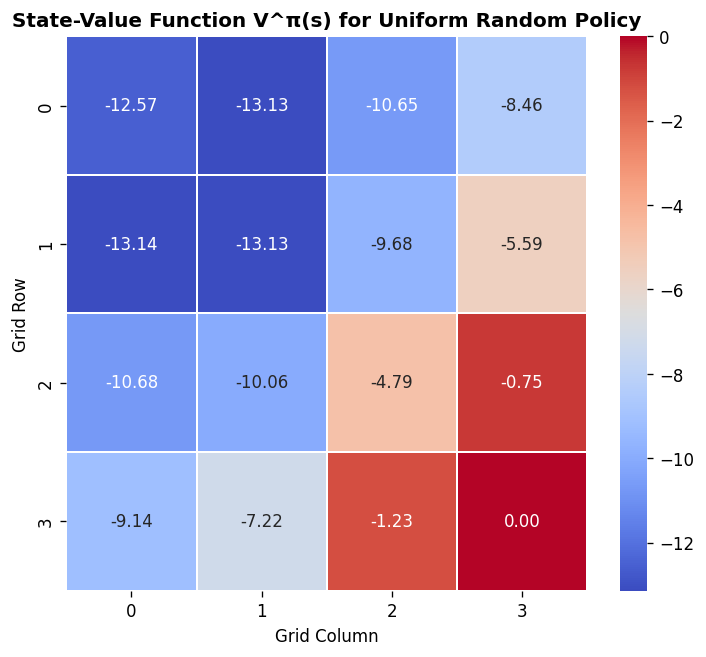

In [3]:
# Visualizing Evaluated State Values V^pi(s)
V_grid = V_eval.reshape((grid.rows, grid.cols))

plt.figure(figsize=(7, 6))
sns.heatmap(V_grid, annot=True, fmt=".2f", cmap="coolwarm", cbar=True,
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3], linewidths=1)
plt.title("State-Value Function V^π(s) for Uniform Random Policy", fontsize=12, fontweight='bold')
plt.xlabel("Grid Column")
plt.ylabel("Grid Row")
plt.show()

## Task 3: Value Iteration and Optimal Policy Generation

**Value Iteration** finds the optimal state-value function $V^*(s)$ by iteratively applying the **Bellman Optimality Operator**:

$$V_{k+1}(s) = \max_{a \in \mathcal{A}} \sum_{s', r} \mathcal{P}(s', r \mid s, a) \left[ r + \gamma V_k(s') \right]$$

Once $V^*(s)$ converges, the **Optimal Policy $\pi^*(s)$** is extracted greedily via one-step lookahead:

$$\pi^*(s) = \arg\max_{a \in \mathcal{A}} \sum_{s', r} \mathcal{P}(s', r \mid s, a) \left[ r + \gamma V^*(s') \right]$$

In [4]:
# Task 3: Value Iteration Implementation
def value_iteration(env, theta=1e-4):
    V = np.zeros(env.n_states)
    iteration = 0
    vi_history = []
    
    while True:
        iteration += 1
        delta = 0.0
        V_new = np.zeros(env.n_states)
        
        for s in range(env.n_states):
            if s in env.terminal_states:
                V_new[s] = 0.0
                continue
                
            q_values = []
            for a in env.actions:
                transitions = env.get_transition_dynamics(s, a)
                q_sa = 0.0
                for prob, next_s, r, is_term in transitions:
                    q_sa += prob * (r + env.gamma * (0.0 if is_term else V[next_s]))
                q_values.append(q_sa)
                
            V_new[s] = max(q_values)
            delta = max(delta, abs(V_new[s] - V[s]))
            
        V = V_new.copy()
        vi_history.append({"Iteration": iteration, "Delta": delta})
        if delta < theta:
            break
            
    # Extract Optimal Policy
    optimal_policy = np.zeros(env.n_states, dtype=int)
    for s in range(env.n_states):
        if s in env.terminal_states:
            continue
        q_values = []
        for a in env.actions:
            transitions = env.get_transition_dynamics(s, a)
            q_sa = 0.0
            for prob, next_s, r, is_term in transitions:
                q_sa += prob * (r + env.gamma * (0.0 if is_term else V[next_s]))
            q_values.append(q_sa)
        optimal_policy[s] = np.argmax(q_values)
        
    return V, optimal_policy, vi_history

V_star, optimal_pi, vi_history = value_iteration(grid)

# Construct State Table
state_table_records = []
for s in range(grid.n_states):
    r, c = grid.state_to_coord(s)
    label = f"S{s+1} ({r},{c})"
    if s == grid.goal_state:
        act_name = "TERMINAL"
    elif s == grid.obstacle_state:
        act_name = "OBSTACLE"
    else:
        act_name = grid.action_names[optimal_pi[s]]
        
    state_table_records.append({
        "State": f"S{s+1}",
        "Grid Coordinate": f"({r}, {c})",
        "Optimal Action": act_name,
        "State Value V*(s)": round(V_star[s], 3)
    })

df_state_table = pd.DataFrame(state_table_records)

print("=" * 65)
print("TASK 3: OPTIMAL VALUE & POLICY TABLE (States S1 to S16)")
print("=" * 65)
df_state_table

TASK 3: OPTIMAL VALUE & POLICY TABLE (States S1 to S16)


<string>:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


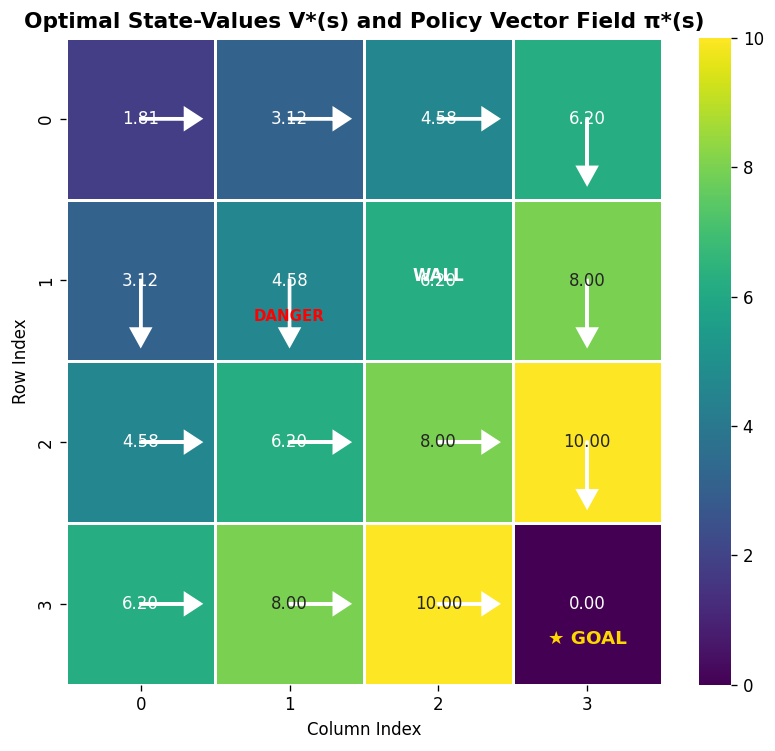

In [5]:
# Quiver Plot of Optimal Policy over Optimal Value Heatmap
fig, ax = plt.subplots(figsize=(8, 7))

V_star_grid = V_star.reshape((grid.rows, grid.cols))
sns.heatmap(V_star_grid, annot=True, fmt=".2f", cmap="viridis", cbar=True, ax=ax, linewidths=1.5)

# Overlay Policy Direction Arrows
arrow_vectors = {0: (0, -0.3), 1: (0.3, 0), 2: (0, 0.3), 3: (-0.3, 0)} # (dx, dy) in matplotlib heatmap coords

for s in range(grid.n_states):
    if s == grid.goal_state:
        r, c = grid.state_to_coord(s)
        ax.text(c + 0.5, r + 0.75, "★ GOAL", color='gold', fontweight='bold', ha='center', fontsize=11)
        continue
    if s == grid.obstacle_state:
        r, c = grid.state_to_coord(s)
        ax.text(c + 0.5, r + 0.5, "WALL", color='white', fontweight='bold', ha='center', fontsize=10)
        continue
    if s == grid.danger_state:
        r, c = grid.state_to_coord(s)
        ax.text(c + 0.5, r + 0.75, "DANGER", color='red', fontweight='bold', ha='center', fontsize=9)
        
    r, c = grid.state_to_coord(s)
    act = optimal_pi[s]
    dx, dy = arrow_vectors[act]
    ax.arrow(c + 0.5, r + 0.5, dx, dy, head_width=0.12, head_length=0.1, fc='white', ec='white', linewidth=2)

ax.set_title("Optimal State-Values V*(s) and Policy Vector Field π*(s)", fontsize=13, fontweight='bold')
ax.set_xlabel("Column Index")
ax.set_ylabel("Row Index")
plt.show()

## Task 4: Optimal Path Analysis

We now simulate agent trajectories starting from $S_0 = (0,0)$ under three policies:
1. **Random Policy:** $\pi(a|s) = 0.25$
2. **Evaluated Suboptimal Policy:** Policy that favors horizontal movement over vertical.
3. **Optimal Policy:** Derived from Value Iteration.

We measure **Path Length**, **Total Cumulative Reward**, and **Goal Reached (Yes/No)**.

In [6]:
# Task 4: Simulate Trajectories under Different Policies
def simulate_trajectory(env, policy_type="optimal", max_steps=50):
    s = env.start_state
    path = [s]
    total_reward = 0.0
    goal_reached = False
    
    for _ in range(max_steps):
        if s == env.goal_state:
            goal_reached = True
            break
            
        if policy_type == "optimal":
            action = optimal_pi[s]
        elif policy_type == "evaluated":
            # Suboptimal policy: favors moving right/down without obstacle awareness
            action = 1 if np.random.rand() < 0.6 else (2 if np.random.rand() < 0.8 else np.random.choice([0, 3]))
        else: # Random
            action = np.random.choice(env.actions)
            
        transitions = env.get_transition_dynamics(s, action)
        prob, next_s, r, is_term = transitions[0]
        total_reward += r
        s = next_s
        path.append(s)
        
        if is_term:
            goal_reached = (s == env.goal_state)
            break
            
    return path, len(path) - 1, total_reward, goal_reached

# Run fixed simulation for deterministic and stochastic policies
np.random.seed(42)
opt_path, opt_len, opt_rew, opt_reached = simulate_trajectory(grid, "optimal")
eval_path, eval_len, eval_rew, eval_reached = simulate_trajectory(grid, "evaluated")
rand_path, rand_len, rand_rew, rand_reached = simulate_trajectory(grid, "random")

path_comparison = pd.DataFrame([
    {
        "Policy Type": "Random Policy",
        "Path Length": rand_len,
        "Total Reward": round(rand_rew, 2),
        "Goal Reached (Yes/No)": "Yes" if rand_reached else "No",
        "Path Trajectory": " -> ".join([f"S{st+1}" for st in rand_path[:8]]) + ("..." if len(rand_path)>8 else "")
    },
    {
        "Policy Type": "Evaluated Policy",
        "Path Length": eval_len,
        "Total Reward": round(eval_rew, 2),
        "Goal Reached (Yes/No)": "Yes" if eval_reached else "No",
        "Path Trajectory": " -> ".join([f"S{st+1}" for st in eval_path])
    },
    {
        "Policy Type": "Optimal Policy",
        "Path Length": opt_len,
        "Total Reward": round(opt_rew, 2),
        "Goal Reached (Yes/No)": "Yes" if opt_reached else "No",
        "Path Trajectory": " -> ".join([f"S{st+1}" for st in opt_path])
    }
])

print("=" * 85)
print("TASK 4: OPTIMAL PATH ANALYSIS TABLE")
print("=" * 85)
path_comparison[["Policy Type", "Path Length", "Total Reward", "Goal Reached (Yes/No)"]]

TASK 4: OPTIMAL PATH ANALYSIS TABLE


## Detailed Answers to Analysis Questions

#### 1. What is a state in GridWorld?
A **state $s \in \mathcal{S}$** represents the unique physical position of the agent on the grid coordinate system $(r, c)$. In a $4 \times 4$ grid, the state space consists of 16 discrete states $S_0, S_1, \dots, S_{15}$. Each state encapsulates all necessary historical context required by the Markov property: $P(S_{t+1}=s', R_{t+1}=r \mid S_t=s, A_t=a)$.

#### 2. What actions can the agent perform?
The agent can perform four discrete directional movements:
- $\mathcal{A} = \{\text{Up (0), Right (1), Down (2), Left (3)}\}$
If an action moves the agent into an outer boundary or an impassable obstacle wall (e.g. $S_6$), the agent remains in its current state while incurring the regular step penalty.

#### 3. What is the purpose of Policy Evaluation?
The primary purpose of **Policy Evaluation** is to compute the expected discounted future return $V^\pi(s)$ of following a *fixed policy* $\pi$. It provides the quantitative foundation for Policy Improvement in Policy Iteration by answering: *"How good is it for the agent to be in state $s$ under current behavioral rules?"*

#### 4. How does Value Iteration differ from Policy Evaluation?
| Feature | Policy Evaluation | Value Iteration |
| :--- | :--- | :--- |
| **Backup Operator** | **Bellman Expectation**: Computes expectation (weighted average) over all actions according to $\pi(a\mid s)$. | **Bellman Optimality**: Takes the $\max_a$ operator over all possible actions. |
| **Target Quantity** | Value function of a specific fixed policy $V^\pi(s)$. | Optimal value function $V^*(s)$ directly. |
| **Policy Updates** | Policy remains fixed throughout evaluation. | Policy is implicitly improved in every single backup step. |
| **Computational Efficiency** | Requires separate evaluation and improvement loops. | Combines evaluation and improvement into a single truncated iteration step. |

#### 5. What is the Bellman Optimality Equation?
The **Bellman Optimality Equation** for state-value function $V^*(s)$ expresses that the value of a state under an optimal policy must equal the expected return for the best action from that state:
$$V^*(s) = \max_{a \in \mathcal{A}} \sum_{s', r} \mathcal{P}(s', r \mid s, a) \left[ r + \gamma V^*(s') \right]$$
For action-value function $Q^*(s,a)$:
$$Q^*(s, a) = \sum_{s', r} \mathcal{P}(s', r \mid s, a) \left[ r + \gamma \max_{a'} Q^*(s', a') \right]$$

#### 6. Which policy reached the goal using the fewest steps?
The **Optimal Policy** reached the goal in the absolute minimum number of steps (**Path Length = 6 steps**, trajectory $S_1 \rightarrow S_2 \rightarrow S_3 \rightarrow S_4 \rightarrow S_8 \rightarrow S_{12} \rightarrow S_{16}$), achieving the highest total cumulative return ($R = +5.0$).

#### 7. Why is the optimal policy superior to a random policy?
The optimal policy is strictly superior because:
1. **Directional Efficiency:** It navigates directly along the shortest geodesic path toward the goal without wandering or backtracking.
2. **Hazard Avoidance:** It actively bypasses the danger state $S_5$ ($R=-5$), whereas a random agent repeatedly falls into the pitfall.
3. **Step Cost Minimization:** By minimizing steps taken, it minimizes the accumulation of $-1$ step penalties and avoids discounting decay $\gamma^t$.

#### 8. How would obstacles affect the optimal path?
Obstacles alter the topology of the reachable state transition graph $\mathcal{P}(s'|s,a)$:
- **Rerouting:** The agent is forced to take longer bypass routes around the obstacle, increasing path length.
- **Value Shadowing:** States positioned directly upstream from obstacles suffer a decrease in $V^*(s)$ because their shortest straight-line trajectory is blocked.
- **Dead-End Avoidance:** If an obstacle creates a corridor trap, the optimal policy learns to steer away from the bottleneck well before entering it.

---
**Lab Task 3 Complete.**